In [18]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [19]:
data_dir = "/home/yihelu/habitat-insect/examples/tutorials"

json_list = []
for file in os.listdir(data_dir):
    if file.endswith('.json'): json_list.append(file)
json_list = np.sort(json_list)

In [20]:
spl = {}
collision = {}
episode = {'start_goal_distance': [], 'shortest_path_length': [], 'scene_id': []}

for data_file in json_list[:]:
    # Open the JSON file
    with open(os.path.join(data_dir, data_file), 'r') as file:
        # Load the contents of the file into a dictionary
        data = json.load(file)

        agent_name, scene_id, episode_id, trial_id = [data[key] for key in ('agent_name', 'scene_id', 'episode_id', 'trial_id')]
        
        if agent_name not in spl:
            spl[agent_name] = {}
            collision[agent_name] = {}
        if episode_id not in spl[agent_name]:
            spl[agent_name][episode_id] = {}    
            collision[agent_name][episode_id] = {}    
        spl[agent_name][episode_id][trial_id] = data['spl']
        collision[agent_name][episode_id][trial_id] = data['collision_count']

        if agent_name == 'ShortestPathFollowerAgent':
            start_goal_distance = np.linalg.norm(np.subtract(data['start_position'], data['goal_position']))
            shortest_path_length = np.sum(np.linalg.norm(np.subtract(data['position'][1:], data['position'][:-1]), axis=1))
            episode['start_goal_distance'].append(start_goal_distance)
            episode['shortest_path_length'].append(shortest_path_length)
            episode['scene_id'].append(scene_id)

In [21]:
data.keys(), spl.keys()

(dict_keys(['trial_name', 'agent_name', 'scene_id', 'episode_id', 'start_position', 'goal_position', 'final_distance_to_goal', 'success', 'spl', 'collision_count', 'position', 'rotation', 'pointgoal_with_gps_compass', 'is_collision', 'angle_to_escape', 'collision_direction', 'trial_id']),
 dict_keys(['BugCX', 'BugMBCX', 'GoalFollower', 'ShortestPathFollowerAgent']))

In [22]:
len(spl['BugCX'].keys()), len(spl['BugMBCX'].keys())

(93, 93)

In [23]:
spl_gf_cx = {'GoalFollower': [], 'BugCX': []}
col_gf_cx = {'GoalFollower': [], 'BugCX': []}
for agent in ('GoalFollower', 'BugCX'):
    for v_spl, v_col in zip(spl[agent].values(), collision[agent].values()):
        spl_gf_cx[agent].append(v_spl['0'])
        col_gf_cx[agent].append(v_col['0'])

In [24]:
def spl_histogram(ax, spl, success):
    counts, bins = np.histogram(100 - np.array(spl) * 100, bins=np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1]) * 100)
    ax.barh(bins[:-1] - 10, np.flip(counts), height=10, align='edge')
    ax.axhline(np.mean(spl) * 100, color='k')
    print(np.mean(success), np.mean(spl))
    return np.mean(spl)

In [25]:
spl_summary = {'first': [], 'last': [], 'mean': [], 'best': [], 'refine': [], 'time2refine': [], 'sorted': [], 'time2best': [], 'time2saturation': []}
success_summary = {'first': [], 'last': [], 'mean': [], 'best': [], 'refine': [], 'sorted': []}
col_summary = {'first': [], 'last': [], 'mean': [], 'best': [], 'refine': [], 'sorted': [], 'time2best': [], 'time2saturation': []}


for spl_all, col_all in zip(spl['BugMBCX'].values(), collision['BugMBCX'].values()):
    spl_trial = []
    col_trial = []
    for trial_id in range(20):
        if str(trial_id) in spl_all:
            spl_val = spl_all[str(trial_id)]
            col_val = col_all[str(trial_id)]
        
        spl_trial.append(spl_val)
        col_trial.append(col_val)

    time2best = np.argmax(spl_trial)

    spl_summary['first'].append(spl_trial[0])
    spl_summary['last'].append(spl_trial[-1])
    spl_summary['mean'].append(np.mean(spl_trial))
    spl_summary['best'].append(np.max(spl_trial))
    spl_summary['time2best'].append(time2best)
    spl_summary['time2saturation'].append(len(spl_all) - 1)
    spl_summary['sorted'].append(np.sort(spl_trial))

    spl_mod = np.hstack((spl_trial, -1))
    diff = np.diff(spl_mod)
    time2refine = np.argmax(diff < 0)
    spl_summary['time2refine'].append(time2refine)
    spl_summary['refine'].append(spl_mod[time2refine])
    success_summary['refine'].append((spl_mod[time2refine] > 0).astype(int))
    col_summary['refine'].append(col_trial[time2refine])
    
    success_summary['first'].append(np.count_nonzero(spl_trial[0]))
    success_summary['last'].append(np.count_nonzero(spl_trial[-1]))
    success_summary['mean'].append(np.count_nonzero(spl_trial) / len(spl_trial))
    success_summary['best'].append(int(np.any(spl_trial)))
    success_summary['sorted'].append(np.sign(np.sort(spl_trial)))

    
    col_summary['first'].append(col_trial[0])
    col_summary['last'].append(col_trial[-1])
    col_summary['mean'].append(np.mean(col_trial))
    col_summary['best'].append(col_trial[time2best])
    col_summary['sorted'].append(np.sort(col_trial))



0.26 0.265202036956531
0.66 0.4674859166452818
0.8387096774193549 0.47379341593464436
0.9247311827956989 0.5895297831454539
0.9247311827956989 0.6490748826471396
0.7096774193548387 0.5000771249356689


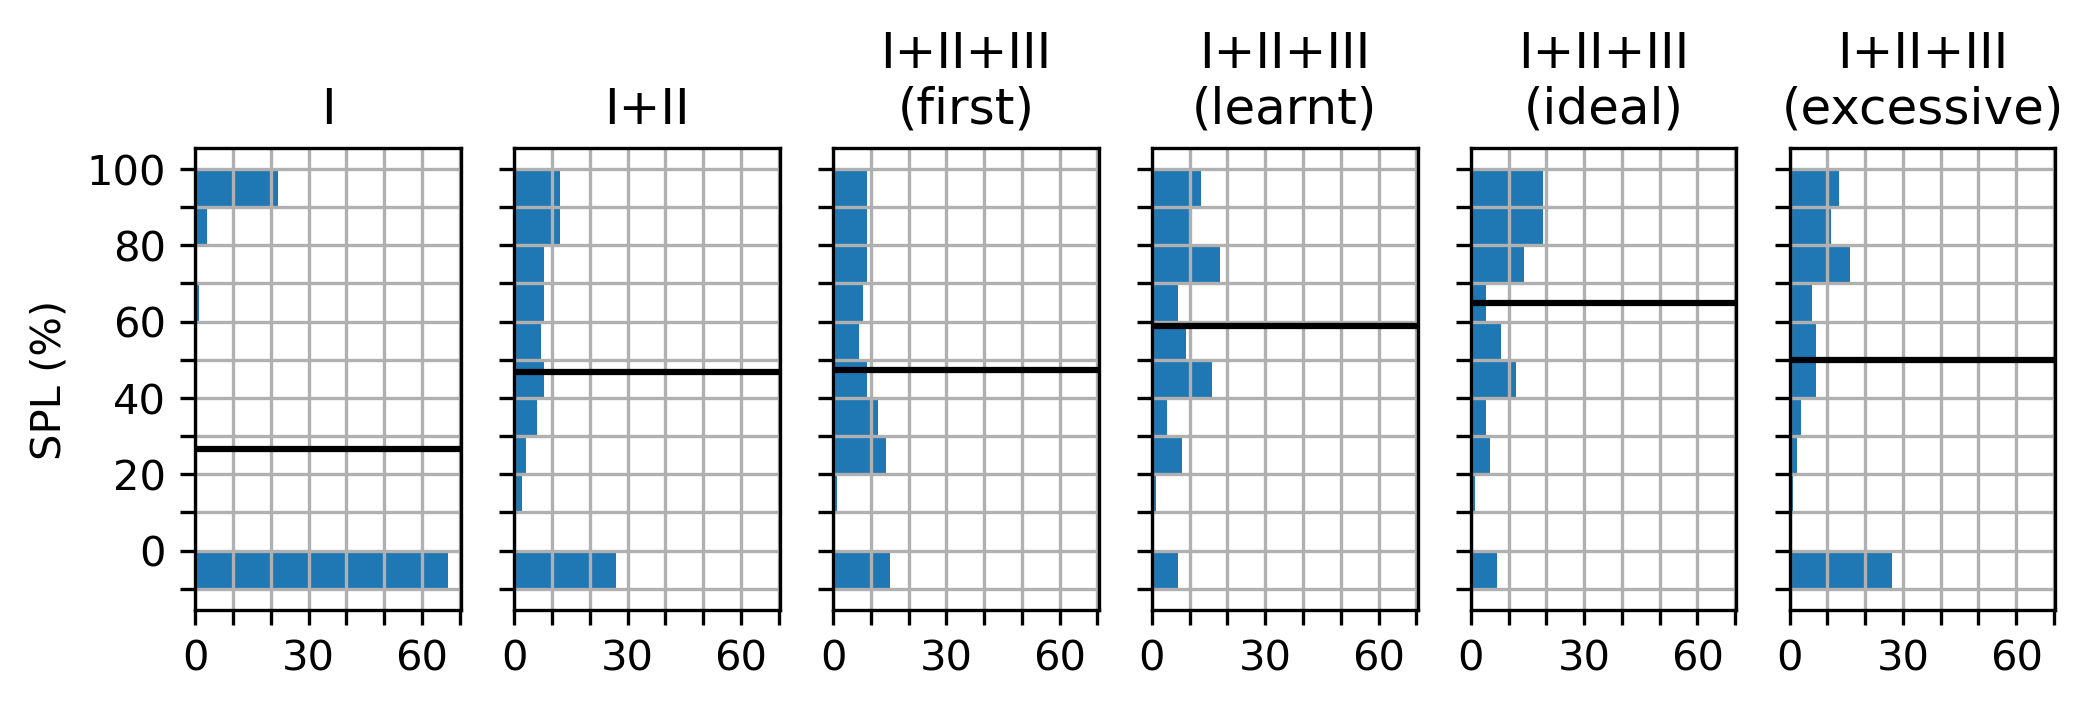

In [26]:
fig, axes = plt.subplots(1, 6, figsize=(8, 2), sharex=True, sharey=True, dpi=300)

col_all = []
n_success = []
mean_spl = []
spl_gcv = []
for ax, key in zip(axes[:2], ('GoalFollower', 'BugCX')):
    mspl = spl_histogram(ax, spl_gf_cx[key], np.count_nonzero(spl_gf_cx[key]) / 100)
    mean_spl.append(mspl)
    n_success.append(np.count_nonzero(spl_gf_cx[key]))
    spl_gcv.append(spl_gf_cx[key])
    col_all.append(col_gf_cx[key])

for ax, key in zip(axes[2:], ('first', 'refine', 'best', 'last')):
    mspl = spl_histogram(ax, spl_summary[key], success_summary[key])
    mean_spl.append(mspl)
    n_success.append(np.count_nonzero(spl_summary[key]))
    spl_gcv.append(spl_summary[key])
    col_all.append(col_summary[key])

model_names = 'I', 'I+II', 'I+II+III\n(first)', 'I+II+III\n(learnt)', 'I+II+III\n(ideal)', 'I+II+III\n(excessive)', 
for ax, key in zip(axes, model_names):
    ax.grid()
    ax.set_xticks(np.arange(0, 71, 10), [0, '', '', 30, '', '', 60, ''])
    ax.set_yticks(np.arange(-10, 101, 10), ['', 0, '', 20, '', 40, '', 60, '', 80, '', 100])
    ax.set_title(key)
    
axes[0].set_ylabel('SPL (%)')


spl_gcv_6 = np.array(spl_gcv)
col_all_6 = np.array(col_all)

# plt.savefig("all-ours-spl.eps", format="eps", bbox_inches="tight", dpi=300)

In [39]:
import json
data_json = {'spl': {}, 'collision': {}}
model_names = ['PI-only', 'PI+escape', 'full-first', 'full-learnt', 'full-hypothetical', 'full-pathological']
for spl, col, key in zip(spl_gcv_6.tolist(), col_all_6.tolist(), model_names):
    data_json['spl'][key] = spl
    data_json['collision'][key] = col

with open("model6habitat.json", "w") as outfile:
    json.dump(data_json, outfile)

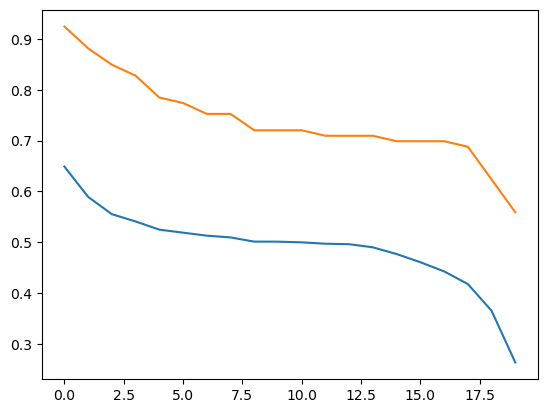

In [28]:
spl_summary['sorted'] = np.array(spl_summary['sorted'])
success_summary['sorted'] = np.array(success_summary['sorted'])

plt.plot(np.flip(np.mean(spl_summary['sorted'], axis=0)))
plt.plot(np.flip(np.mean(success_summary['sorted'], axis=0)))
# for agent in ('GoalFollower', 'BugCX'):
#     mean_spl = np.mean(spl_gf_cx[agent])
#     mean_success = np.count_nonzero(spl_gf_cx[agent]) / len(spl_gf_cx[agent])
#     print(mean_spl, mean_success)
#     plt.axhline(mean_spl)
#     plt.axhline(mean_success, color='tab:orange')

def waterfall(ax, success_data, x0=0.5):
    for x, (left, right) in enumerate(zip(success_data[:-1], success_data[1:])):
        diff = right - left
        n_pos = np.count_nonzero(diff > 0)
        n_neg = np.count_nonzero(diff < 0)
        for pm, data, c, base in zip((1, -1), (n_pos, n_neg), 'gr', (left, right)):
            xx = x0 + x - pm *0
            yy = np.count_nonzero(left)
            if data != 0:
                ax.bar(xx, data * pm, bottom=yy, facecolor='none', edgecolor=c, width=0.35, ls='dotted')
            # else:
            #     ax.plot([xx - 0.1, xx + 0.1], [yy, yy], color=c, lw=0.9, ls='dotted')

fig, ax = plt.subplots(figsize=(6, 3), dpi=300)

ax.bar(np.arange(6), n_success, width=0.6, label='success rate')
ax.bar(np.arange(6), np.array(mean_spl) * 100, width=0.3, label='SPL')

# waterfall(ax, (spl_gcv[:-1] > 0).astype(int))
# ax.scatter([], [], s=100, marker='s', facecolor='none', edgecolor='g', lw=0.9, ls='dotted', label='failure to success')
# ax.scatter([], [], s=100, marker='s', facecolor='none', edgecolor='r', lw=0.9, ls='dotted', label='success to failure')

ax.set_ylabel('performance (%)')
ax.set_ylim(top=100)
ax.legend(loc=4)


ax.set_xticks(np.arange(0, 5.1, 0.5),
              ['G', r'$\rightarrow$', 'GC', r'$\rightarrow$', 'GCV\n(first)', r'$\rightarrow$', 'GCV\n(best)', r'$\rightarrow$', 'GCV\n(refined)', r'$\rightarrow$', 'GCV\n(last)'])# np.insert(model_names[:-1], [1, 2, 3, 4], r'$\rightarrow$'))


ax.grid()


# plt.savefig("model-performance.pdf", format="pdf", bbox_inches="tight", dpi=300)

fig, axes = plt.subplots(1, 2, figsize=(8, 2), gridspec_kw={'width_ratios': [1, 5]}, dpi=300)
axes[0].violinplot(col_all_6[0], showextrema=False, showmeans=True)
axes[1].violinplot(col_all_6[1:].T, showextrema=False, showmeans=True)

for ax in axes:
    ax.grid()
    
axes[0].set_xticks([1], [model_names[0]])
axes[1].set_xticks(np.arange(1, 5.5, 1), model_names[1:])
    
axes[0].set_ylim(-10, 510)
axes[0].set_yticks(np.arange(0, 501, 100))
axes[1].set_ylim(-1, 51)
axes[1].set_yticks(np.arange(0, 51, 10))



axes[0].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

fig.tight_layout()

plt.savefig("habitat-collision.pdf", format="pdf", bbox_inches="tight", dpi=300)

In [29]:
hardtaskid = np.nonzero(spl_gcv_6[1] == 0)[0]
n_hard = hardtaskid.size

In [30]:
total_task = 100
spl_gcv = spl_gcv_6[:4]
col_all = col_all_6[:4]

[27.95698925 70.96774194 83.87096774 92.47311828]
[26.5202037  46.74859166 47.37934159 58.95297831]


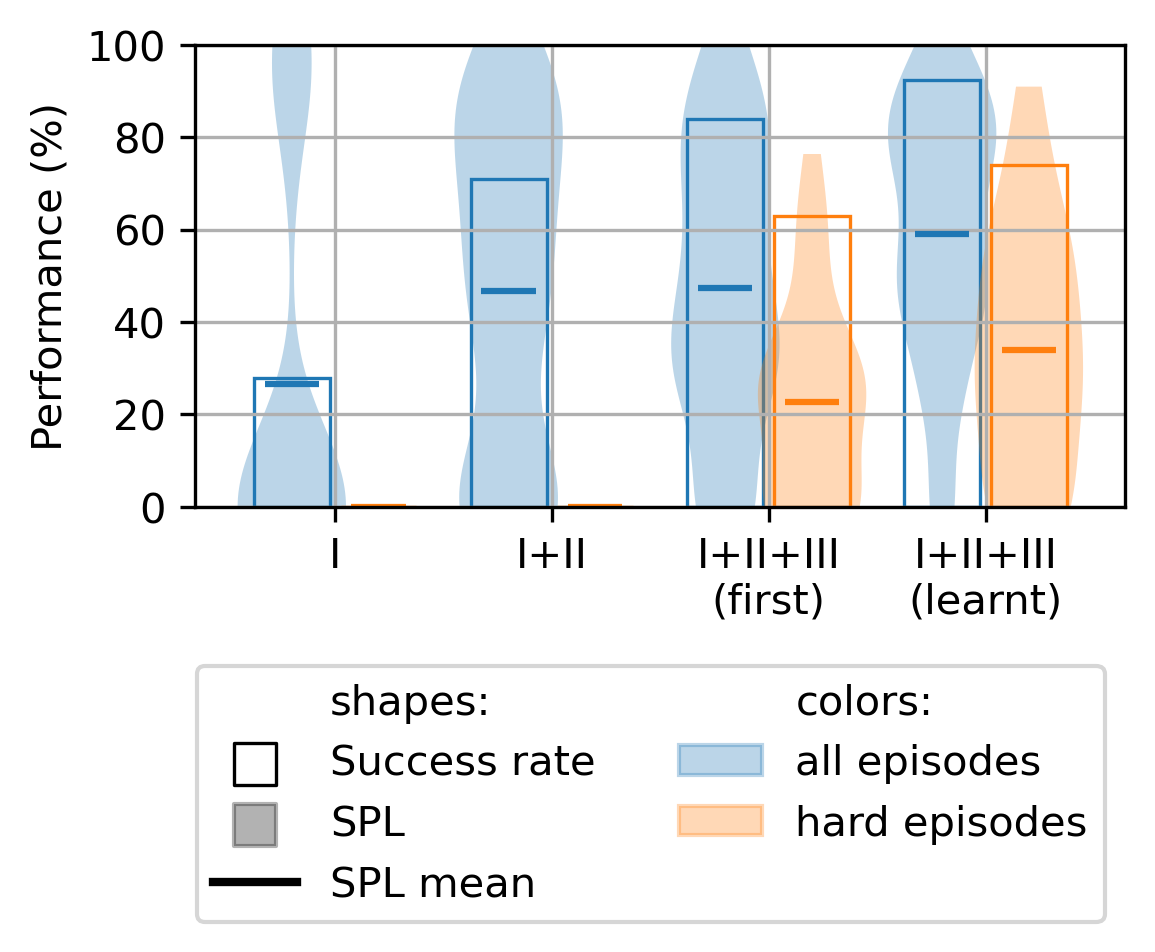

In [31]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=300)
xx = np.arange(len(spl_gcv))

print(np.mean((spl_gcv > 0).astype(int) * 100, axis=1))
print(np.mean(spl_gcv * 100, axis=1))
ax.bar(xx - 0.2, np.mean((spl_gcv > 0).astype(int) * 100, axis=-1), 
       width=0.35, fill=False, edgecolor='tab:blue', lw=0.8)
ax.violinplot(spl_gcv.T *100, positions=xx - 0.2,
              showextrema=False, showmeans=True)

ax.bar(xx + 0.2, np.mean((spl_gcv[:, hardtaskid] > 0).astype(int) * 100, axis=-1), 
       width=0.35, fill=False, edgecolor='tab:orange', lw=0.8)
ax.violinplot(spl_gcv[:, hardtaskid].T*100, positions=xx + 0.2,
              showextrema=False, showmeans=True)

ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 5.5, 1), model_names)
ax.set_ylabel('Performance (%)')
# ax.set_title('$N={}, M={}$'.format(total_task, n_hard), loc='right')
ax.grid()

ax.scatter([], [], marker='None', label='shapes:')
ax.scatter([], [], label='Success rate', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=100)
ax.scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=100)
ax.plot([], [], label='SPL mean', color='k', lw=2)

ax.scatter([], [], marker='None', label='colors:')
ax.fill_between([], [], [], [], color='tab:blue', alpha=0.3, label='all episodes')
ax.fill_between([], [], [], [], color='tab:orange', alpha=0.3, label='hard episodes')


ax.legend(ncol=2, loc='upper right', bbox_to_anchor=(1,-0.3))


plt.savefig("habitat-performance.pdf", format="pdf", bbox_inches="tight", dpi=300)

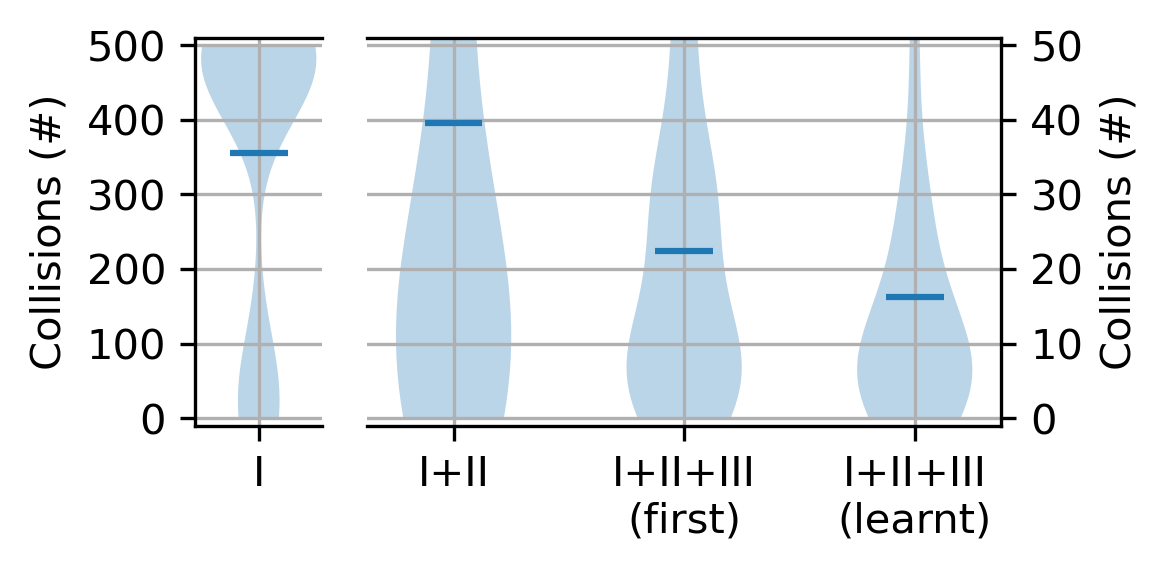

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2), gridspec_kw={'width_ratios': [1, 5]}, dpi=300)
axes[0].violinplot(col_all[0], showextrema=False, showmeans=True)
axes[1].violinplot(col_all[1:].T, showextrema=False, showmeans=True)

for ax in axes:
    ax.grid()
    
axes[0].set_xticks([1], ['I'])
axes[1].set_xticks(np.arange(1, 3.5, 1), ['I+II', 'I+II+III\n(first)', 'I+II+III\n(learnt)'])
    
axes[0].set_ylim(-10, 510)
axes[0].set_yticks(np.arange(0, 501, 100))
axes[1].set_ylim(-1, 51)
axes[1].set_yticks(np.arange(0, 51, 10))



axes[0].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

for ax in axes:
    ax.set_ylabel('Collisions (#)')

fig.tight_layout()

plt.savefig("habitat-collision.pdf", format="pdf", bbox_inches="tight", dpi=300)

In [33]:
spl_gcv = spl_gcv_6[[3, 4, 5]]
col_all = col_all_6[[3, 4, 5]]

[92.47311828 92.47311828 70.96774194]
[58.95297831 64.90748826 50.00771249]


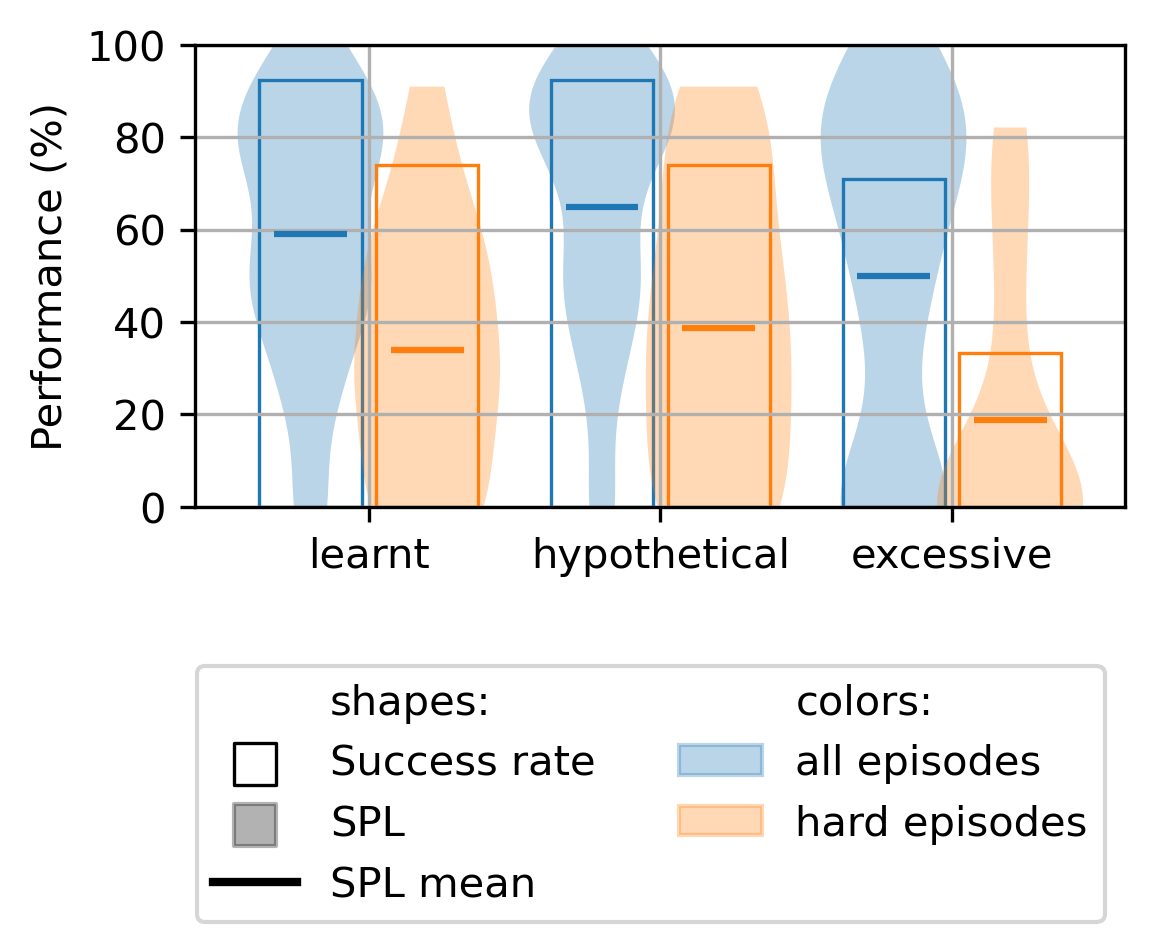

In [34]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=300)
xx = np.arange(len(spl_gcv))

print(np.mean((spl_gcv > 0).astype(int) * 100, axis=1))
print(np.mean(spl_gcv * 100, axis=1))
ax.bar(xx - 0.2, np.mean((spl_gcv > 0).astype(int) * 100, axis=-1), 
       width=0.35, fill=False, edgecolor='tab:blue', lw=0.8)
ax.violinplot(spl_gcv.T *100, positions=xx - 0.2,
              showextrema=False, showmeans=True)

ax.bar(xx + 0.2, np.mean((spl_gcv[:, hardtaskid] > 0).astype(int) * 100, axis=-1), 
       width=0.35, fill=False, edgecolor='tab:orange', lw=0.8)
ax.violinplot(spl_gcv[:, hardtaskid].T*100, positions=xx + 0.2,
              showextrema=False, showmeans=True)

ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 2.5, 1), 
              ['learnt', 'hypothetical', 'excessive'])
ax.set_ylabel('Performance (%)')
# ax.set_title('$N={}, M={}$'.format(total_task, n_hard), loc='right')
ax.grid()

ax.scatter([], [], marker='None', label='shapes:')
ax.scatter([], [], label='Success rate', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=100)
ax.scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=100)
ax.plot([], [], label='SPL mean', color='k', lw=2)

ax.scatter([], [], marker='None', label='colors:')
ax.fill_between([], [], [], [], color='tab:blue', alpha=0.3, label='all episodes')
ax.fill_between([], [], [], [], color='tab:orange', alpha=0.3, label='hard episodes')


ax.legend(ncol=2, loc='upper right', bbox_to_anchor=(1,-0.3))


plt.savefig("habitat-performance-memory-effect.pdf", format="pdf", bbox_inches="tight", dpi=300)

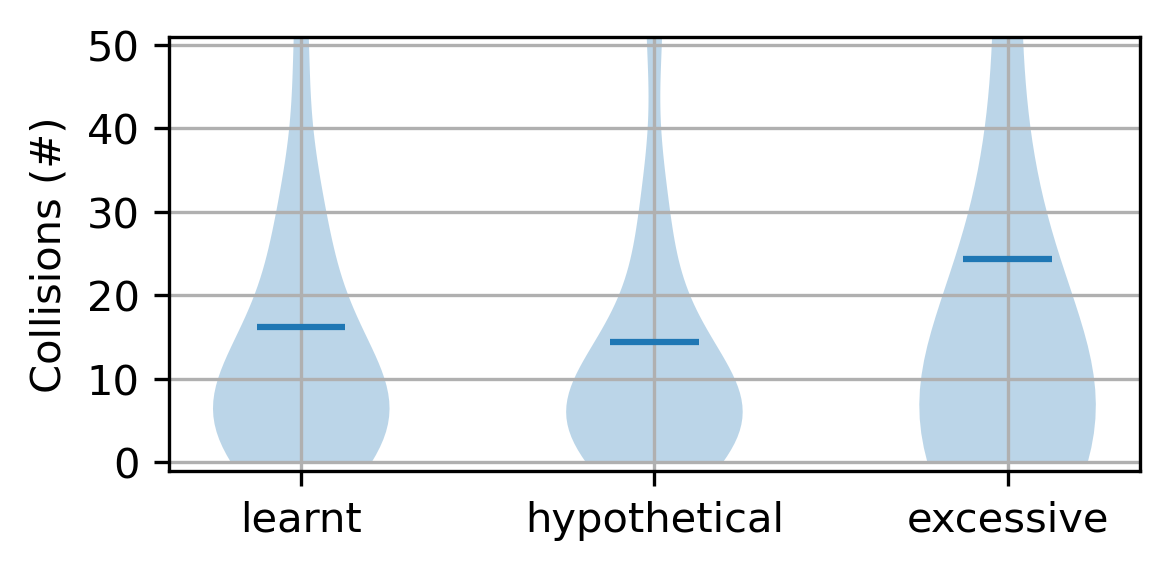

In [35]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=300)

ax.violinplot(col_all.T, showextrema=False, showmeans=True)

ax.grid()
ax.set_xticks(np.arange(1, 3.5, 1), ['learnt', 'hypothetical', 'excessive'])    


ax.set_ylim(-1, 51)
ax.set_yticks(np.arange(0, 51, 10))

# axes[1].spines['left'].set_visible(False)
# axes[1].yaxis.set_label_position("right")
# axes[1].yaxis.tick_right()

ax.set_ylabel('Collisions (#)')

fig.tight_layout()

plt.savefig("habitat-collision-memory-effect.pdf", format="pdf", bbox_inches="tight", dpi=300)

[28. 72. 84. 92. 72.]


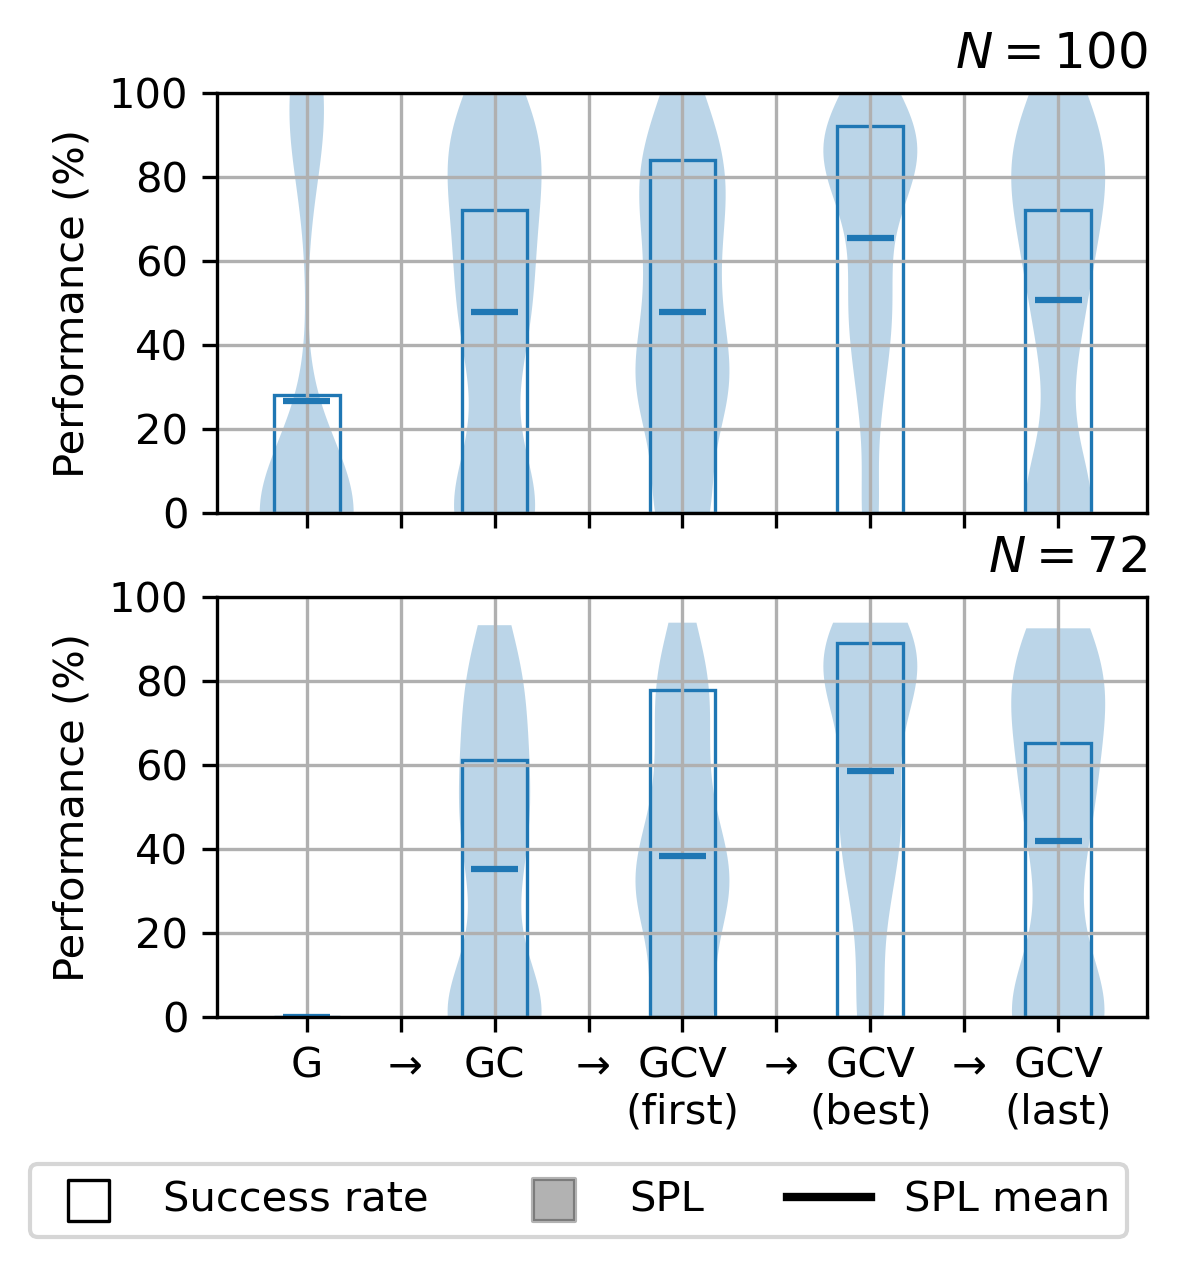

In [39]:
fig, (ax, bx) = plt.subplots(2, 1, figsize=(4, 4), dpi=300, sharex=True)

print(np.mean((spl_gcv[:-1] > 0).astype(int) * 100, axis=-1))
ax.bar(np.arange(5), np.mean((spl_gcv[:-1] > 0).astype(int) * 100, axis=-1), 
       width=0.35, fill=False, edgecolor='tab:blue', lw=0.8)
ax.violinplot(spl_gcv[:-1].T, positions=np.arange(5),
              showextrema=False, showmeans=True)

bx.bar(np.arange(5), np.mean((spl_gcv[:-1, hardtaskid] > 0).astype(int) * 100, axis=-1), 
       width=0.35, fill=False, edgecolor='tab:blue', lw=0.8)
bx.violinplot(spl_gcv[:-1, hardtaskid].T, positions=np.arange(5),
              showextrema=False, showmeans=True)

for a, n in zip([ax, bx], [total_task, n_hard]):
    a.set_ylim(0, 100)
    a.set_xticks(np.arange(0, 4.5, 0.5), ['G', r'$\rightarrow$', 'GC', r'$\rightarrow$', 'GCV\n(first)', r'$\rightarrow$', 'GCV\n(best)', r'$\rightarrow$', 'GCV\n(last)'])
    a.set_ylabel('Performance (%)')
    a.set_title('$N={}$'.format(n), loc='right')
    a.grid()

bx.scatter([], [], label='Success rate', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=100)
bx.scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=100)
bx.plot([], [], label='SPL mean', color='k', lw=2)
bx.legend(ncol=3, loc='upper right', bbox_to_anchor=(1,-0.3))

plt.savefig("habitat-performance.pdf", format="pdf", bbox_inches="tight", dpi=300)

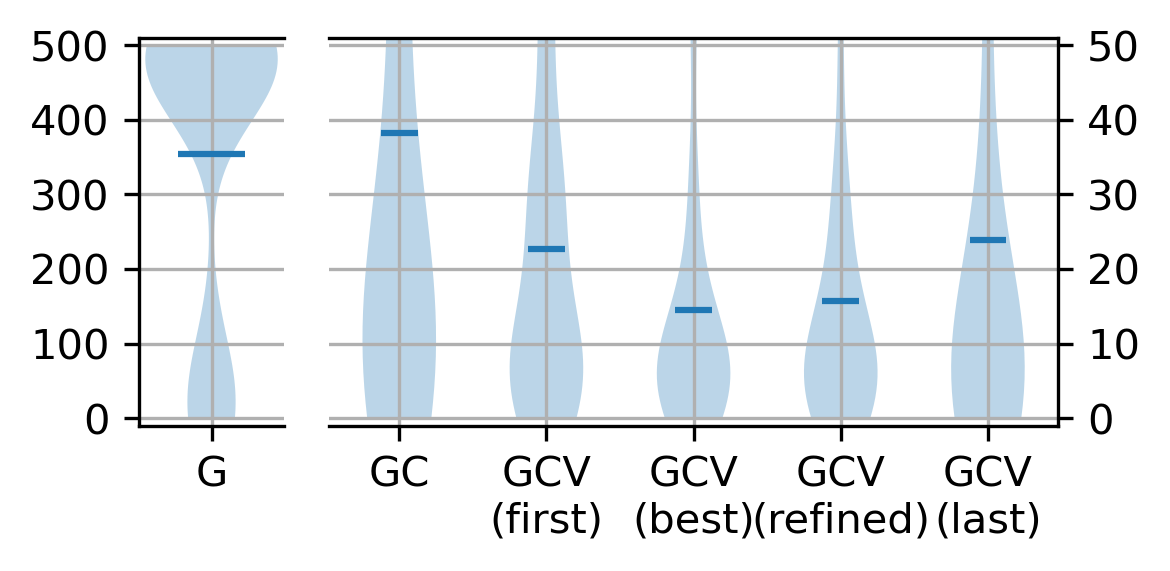

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2), gridspec_kw={'width_ratios': [1, 5]}, dpi=300)
axes[0].violinplot(col_all[0], showextrema=False, showmeans=True)
axes[1].violinplot(col_all[1:].T, showextrema=False, showmeans=True)

for ax in axes:
    ax.grid()
    
axes[0].set_xticks([1], ['G'])
axes[1].set_xticks(np.arange(1, 5.5, 1), ['GC', 'GCV\n(first)', 'GCV\n(best)', 'GCV\n(refined)', 'GCV\n(last)'])
    
axes[0].set_ylim(-10, 510)
axes[0].set_yticks(np.arange(0, 501, 100))
axes[1].set_ylim(-1, 51)
axes[1].set_yticks(np.arange(0, 51, 10))



axes[0].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

fig.tight_layout()

plt.savefig("habitat-collision.pdf", format="pdf", bbox_inches="tight", dpi=300)

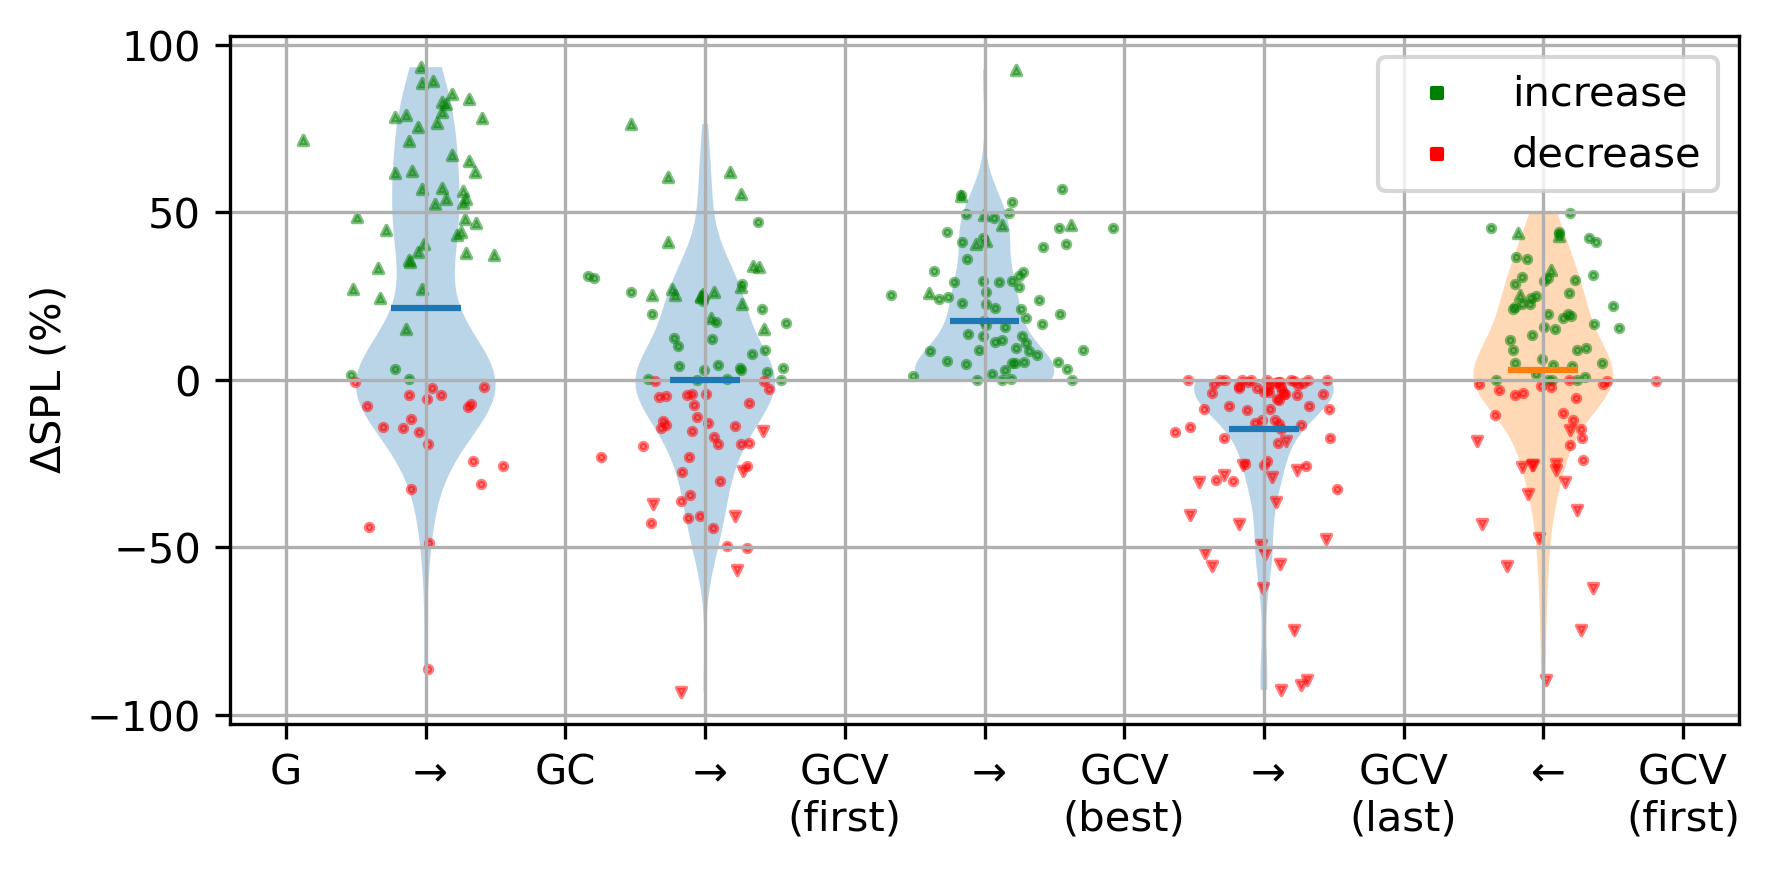

In [35]:
fig, bx = plt.subplots(figsize=(6, 3), dpi=300, layout='tight')


####

spl_gcv_diff = (spl_gcv[1:-1] - spl_gcv[:-2]) * 100
bx.violinplot(spl_gcv_diff.T, positions=[0.5, 1.5, 2.5, 3.5],
           showmeans=True, showextrema=False)

for x, (diff, right, left) in enumerate(zip(spl_gcv_diff, spl_gcv[1:-1], spl_gcv[:-2])):
    for idx, c in zip((diff > 0, diff < 0), 'gr'):
        if np.count_nonzero(idx) > 0:
            yy = diff
            xx = np.random.normal(x + 0.5, 0.15, 100)

            if c == 'g':            
                bx.scatter(xx[idx & (left!=0)], yy[idx & (left!=0)], color=c, s=3, alpha=0.5)
                bx.scatter(xx[(left==0) & (right > 0)], yy[(left==0) & (right > 0)], color=c, s=5, alpha=0.5, marker='^')
            elif c == 'r':
                bx.scatter(xx[idx & (right!=0)], yy[idx & (right!=0)], color=c, s=3, alpha=0.5)
                bx.scatter(xx[(left>0) & (right == 0)], yy[(left>0) & (right == 0)], color=c, s=5, alpha=0.5, marker='v')


############################
right, left = spl_gcv[4], spl_gcv[2]
diff = (right - left) * 100

bx.violinplot(diff, positions=[4.5],
           showmeans=True, showextrema=False)
for idx, c in zip((diff > 0, diff < 0), 'gr'):
    if np.count_nonzero(idx) > 0:
        yy = diff
        xx = np.random.normal(4.5, 0.15, 100)

        if c == 'g':            
            bx.scatter(xx[idx & (left!=0)], yy[idx & (left!=0)], color=c, s=3, alpha=0.5)
            bx.scatter(xx[(left==0) & (right > 0)], yy[(left==0) & (right > 0)], color=c, s=5, alpha=0.5, marker='^')
        elif c == 'r':
            bx.scatter(xx[idx & (right!=0)], yy[idx & (right!=0)], color=c, s=3, alpha=0.5)
            bx.scatter(xx[(left>0) & (right == 0)], yy[(left>0) & (right == 0)], color=c, s=5, alpha=0.5, marker='v')



for c, lb in zip('gr', ['increase', 'decrease']):
    bx.scatter([], [], color=c, s=5, label=lb, marker='s')


bx.set_ylabel(r'$\Delta$SPL (%)')
bx.set_xticks(np.arange(0, 5.1, 0.5), ['G', r'$\rightarrow$', 'GC', r'$\rightarrow$', 'GCV\n(first)', r'$\rightarrow$', 'GCV\n(best)', r'$\rightarrow$', 'GCV\n(last)', r'$\leftarrow$', 'GCV\n(first)'])# np.insert(model_names[:-1], [1, 2, 3, 4], r'$\rightarrow$'))
# bx.set_yticks(np.linspace(-100, 100, 9))
bx.legend()

bx.grid()
bx.set_xlim(-0.2, 5.2)
    # a.set_rasterized(True)


plt.savefig("double-edge.pdf", format="pdf", bbox_inches="tight", dpi=300)

2.5
7.2


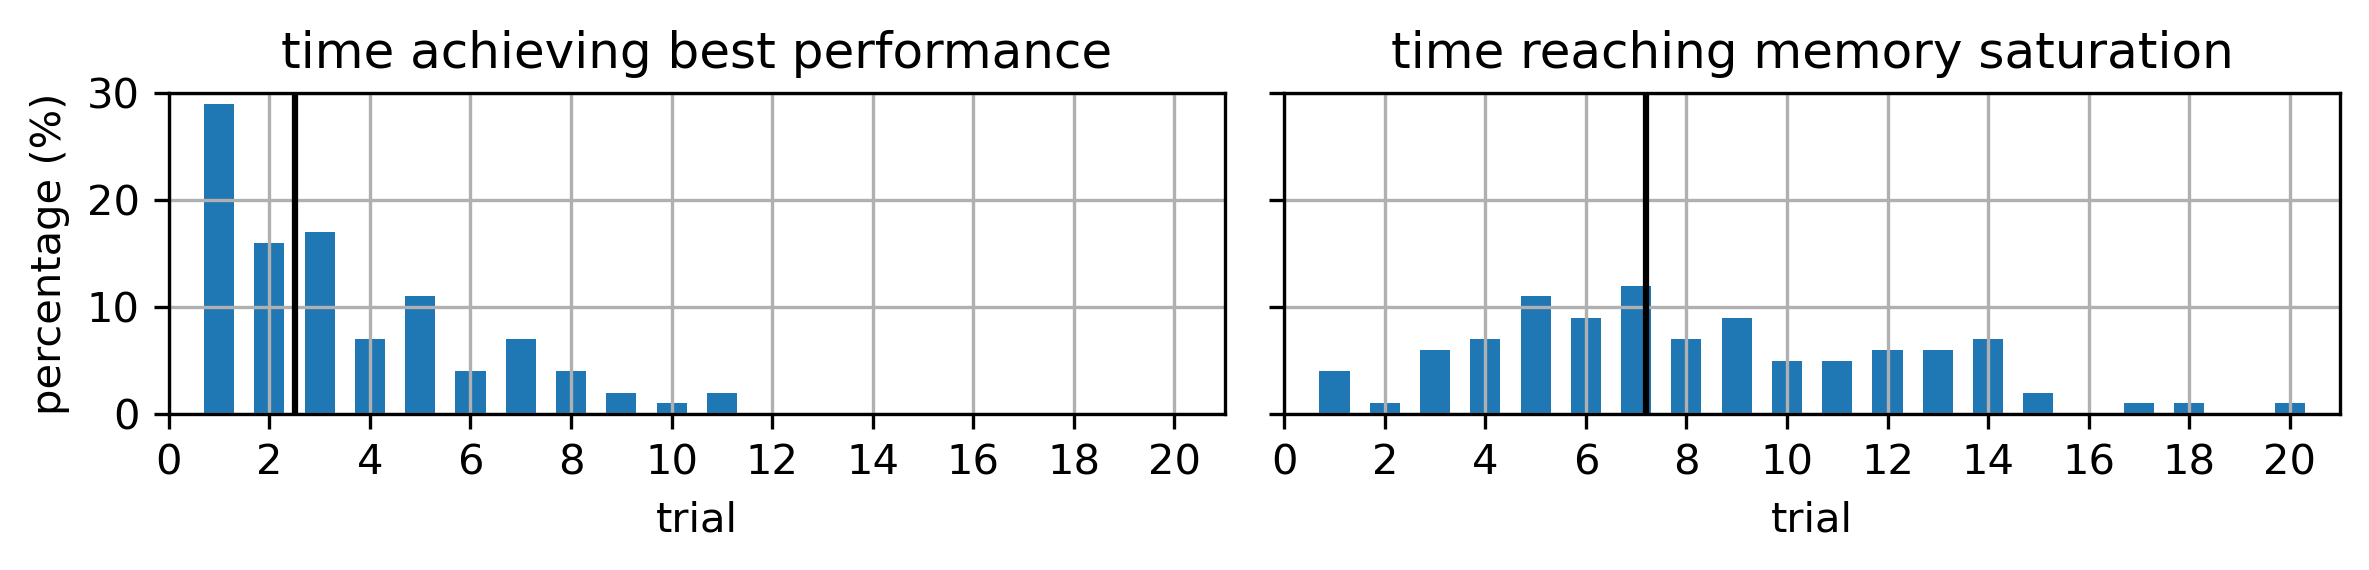

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(8, 2), dpi=300, sharex=False, sharey=True, layout='tight')

for ax, key in zip(axes, ['time2best', 'time2saturation']):
    values, counts = np.unique(np.array(spl_summary[key]), return_counts=True)
    ax.bar(values + 1, counts, width=0.6)
    sm = np.mean(spl_summary[key])
    print(sm)
    ax.axvline(sm, color='k')

for ax, lb in zip(axes, ['time achieving best performance', 'time reaching memory saturation']):
    ax.grid()
    ax.set_xticks(np.arange(0, 21, 2))
    ax.set_xlim(0, 21)
    ax.set_xlabel('trial')
    ax.set_title(lb)
    ax.set_ylim(0, 30)

axes[0].set_ylabel('percentage (%)')

plt.savefig("time2best-saturation.pdf", format="pdf", bbox_inches="tight", dpi=300)

In [157]:
# maybe also plot how performance improvement varies as function of these trials

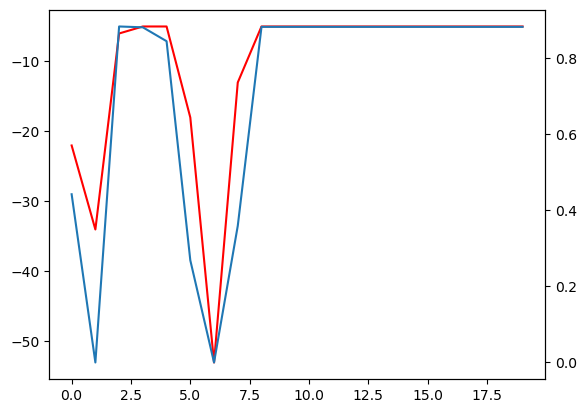

In [74]:
plt.plot(-np.array(col_trial), color='r')
plt.twinx().plot(spl_trial)

0.84 22.69
0.72 23.83
0.7485000000000003 23.6255
0.92 44.21


Text(0, 0.5, 'spl')

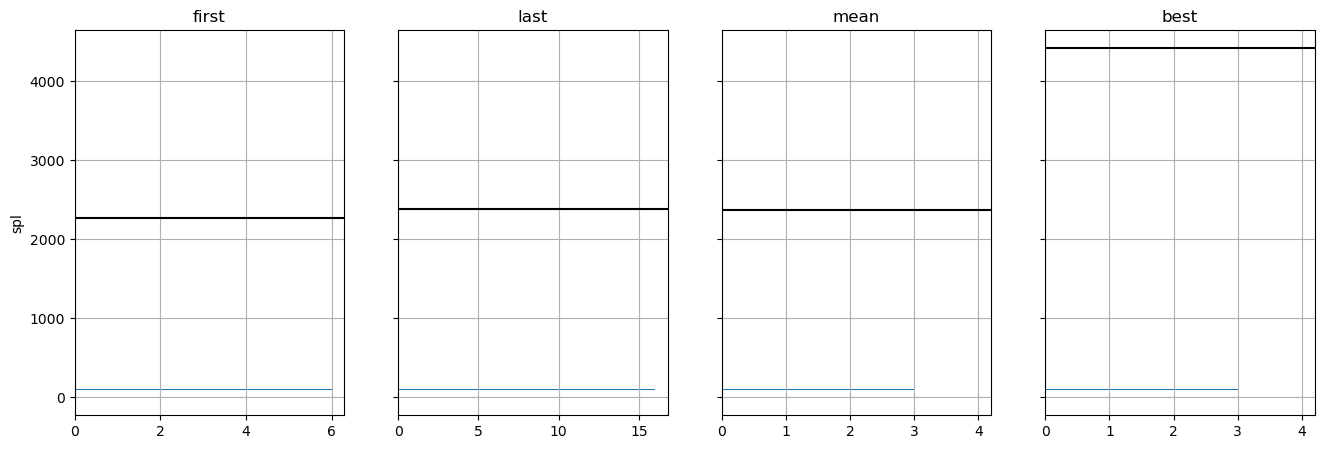

In [158]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for ax, key in zip(axes, ('first', 'last', 'mean', 'best')):
    spl_histogram(ax, col_summary[key], success_summary[key])
    ax.set_title(key)
    ax.grid()

axes[0].set_ylabel('spl')

# relations between performance and task difficulty
what IS task difficulty?

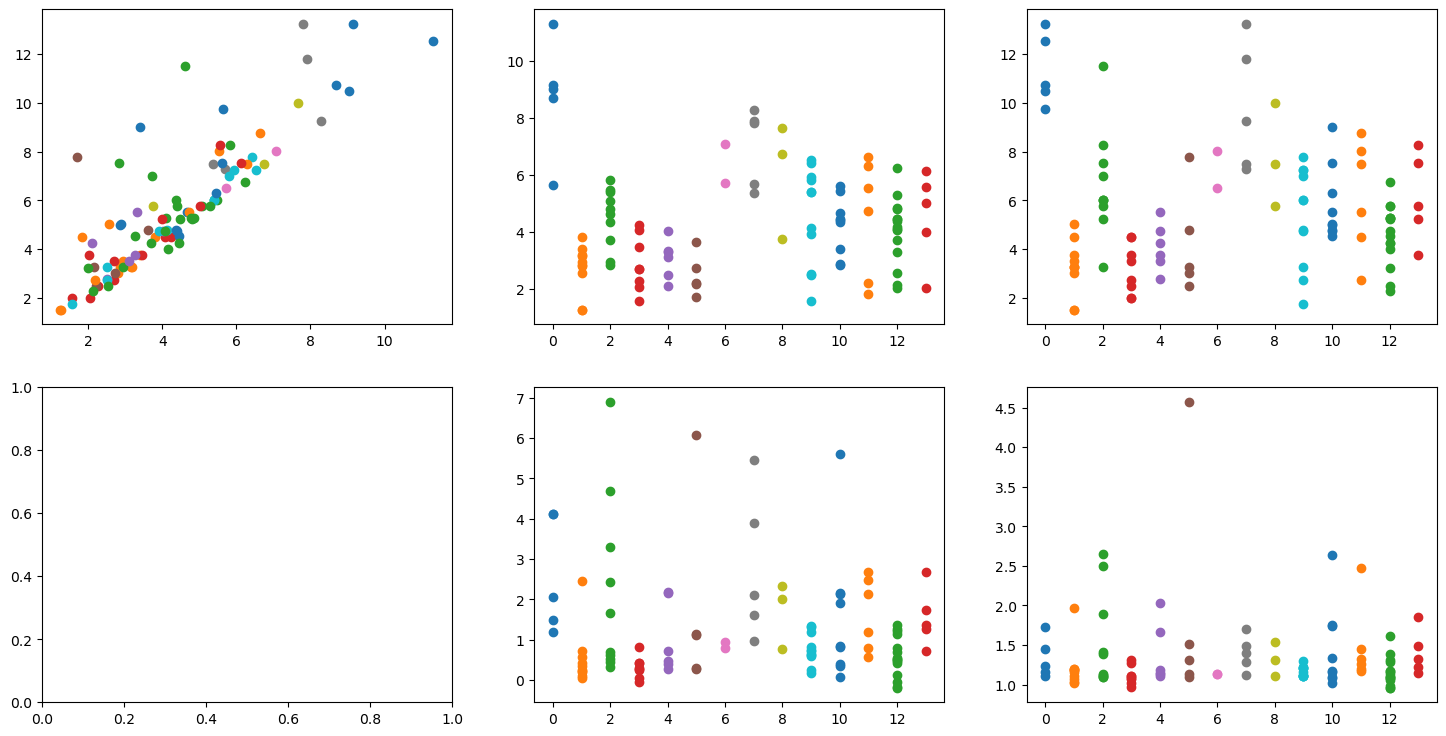

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for cat, key in enumerate(np.unique(episode['scene_id'])):
    idx = np.array(episode['scene_id']) == key
    x, y = np.array(episode['start_goal_distance'])[idx], np.array(episode['shortest_path_length'])[idx]
    axes[0, 0].scatter(x, y)

    axes[0, 1].scatter(np.full_like(x, cat), x)
    axes[0, 2].scatter(np.full_like(y, cat), y)
    axes[1, 1].scatter(np.full_like(y, cat), y - x)
    axes[1, 2].scatter(np.full_like(y, cat), y / x)

In [13]:
from scipy.stats import linregress
from scipy.optimize import curve_fit
def sigmoid(x, k, x0):
    return 1 / (1 + np.exp(-k * (x - x0)))

def exponential(x, k, x0):
    return np.exp(-k * x) * x0

In [14]:
xs = episode['start_goal_distance'], \
    episode['shortest_path_length'], \
    np.subtract(episode['shortest_path_length'], episode['start_goal_distance']), \
    np.divide(episode['shortest_path_length'], episode['start_goal_distance'])

def scatter_plot(xs, yy):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for ax, xx in zip(axes, xs):
        ax.scatter(xx, yy)

        popt, pcov, infodict, mesg, _ = curve_fit(sigmoid, xx, yy, maxfev=1000, full_output=True)
        xxx = np.linspace(np.min(xx), np.max(xx), 100)
        yyy = sigmoid(xxx, *popt)
        ax.plot(xxx, yyy, c='r')
        rss = np.sum(infodict['fvec']**2)
        print(*popt, rss)

        # slope, intercept, r_value, p_value, std_err = linregress(xx, yy)
        # print(r_value)
        # linear or exponential gives slightly worse fit (less sensible, anyway)


-0.1250173258335327 3.661102724680083 12.338983291253479
-0.15372012679759503 4.993758600502555 11.837911688869172
-0.3540167397003841 0.9152554299905885 11.794080308692548
-0.6689974113291107 1.1845275874002938 12.256458758108776


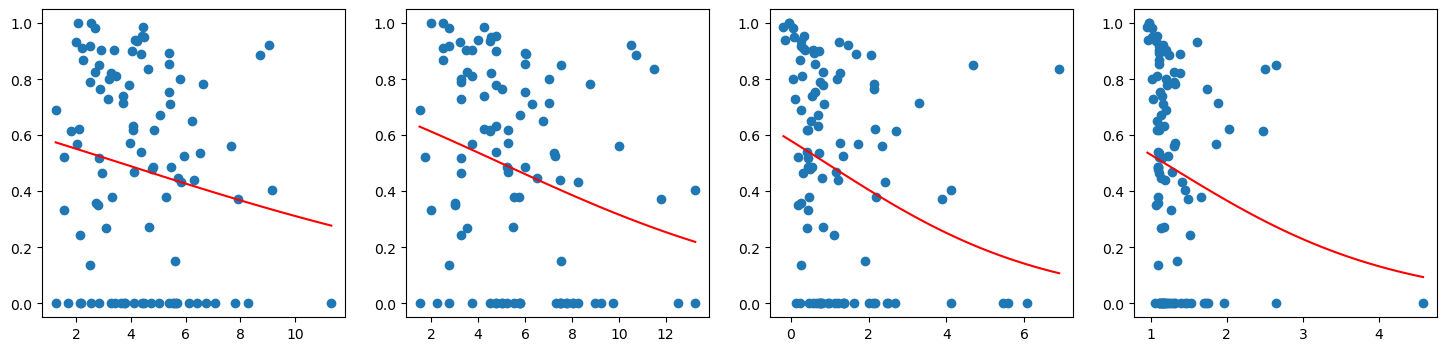

In [15]:
scatter_plot(xs, spl_gf_cx['BugCX'])

2.1870612411998364e-06 -292778.4401770884 8.423232487056344
1.1902486577804484e-06 -537976.7419767736 8.423232768122192
-0.23925726040383047 3.9689301615765467 7.841250861281732
1.7884434622361077e-05 -35802.58428139496 8.423232451177904


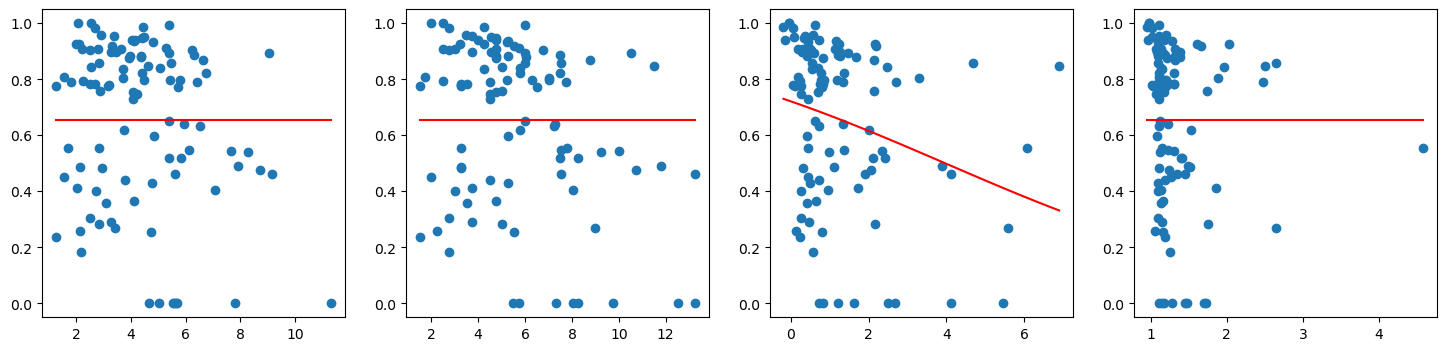

In [16]:
scatter_plot(xs, spl_summary['best'])

-0.18559981623066385 4.355298315338018 10.033346438256185
-0.20007803996094833 5.61359272058141 9.31939352044556
-0.41082466612808793 1.151431096627228 9.567185647035824
-0.6093790018531283 1.3068645505569998 10.432634029858487


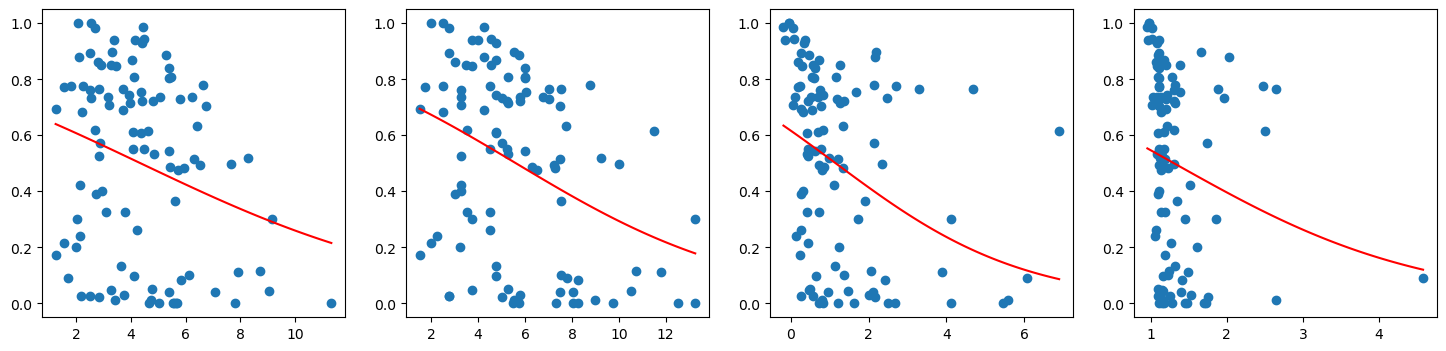

In [17]:
scatter_plot(xs, spl_summary['mean'])

-0.22590654438211727 3.954092883012102 8.471471320319568
-0.1818005577346874 5.113785273105975 8.280788049804286
-0.25289479338469956 0.8442116263186383 9.007002819416762
-0.10041387139823432 0.463630626075251 9.51492067693821


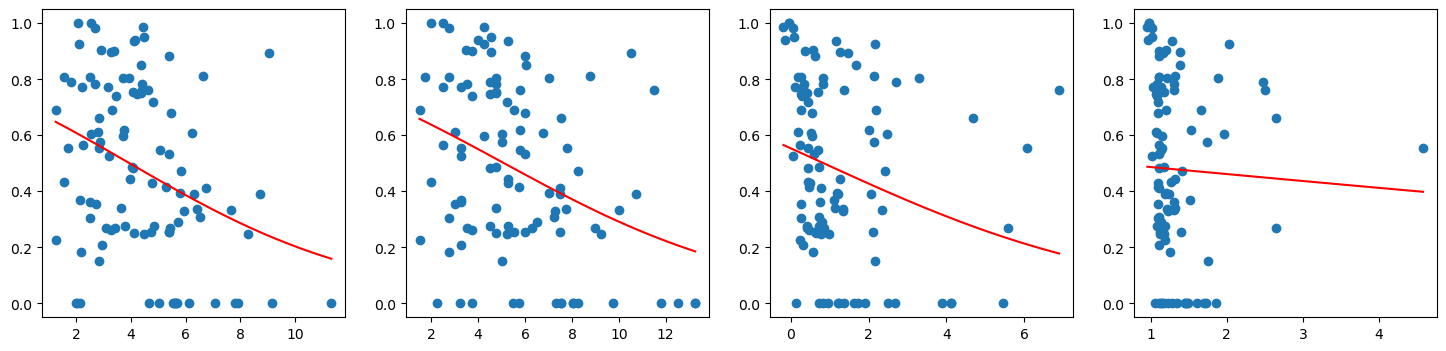

In [18]:
scatter_plot(xs, spl_summary['first'])

-0.17479046573945553 4.569640134845865 12.374690487684806
-0.1912203321791513 5.814018511544211 11.691799327367766
-0.4029533728068854 1.2430604195439152 11.876672799310088
-0.6044090935860587 1.3694303299960942 12.664818071648373


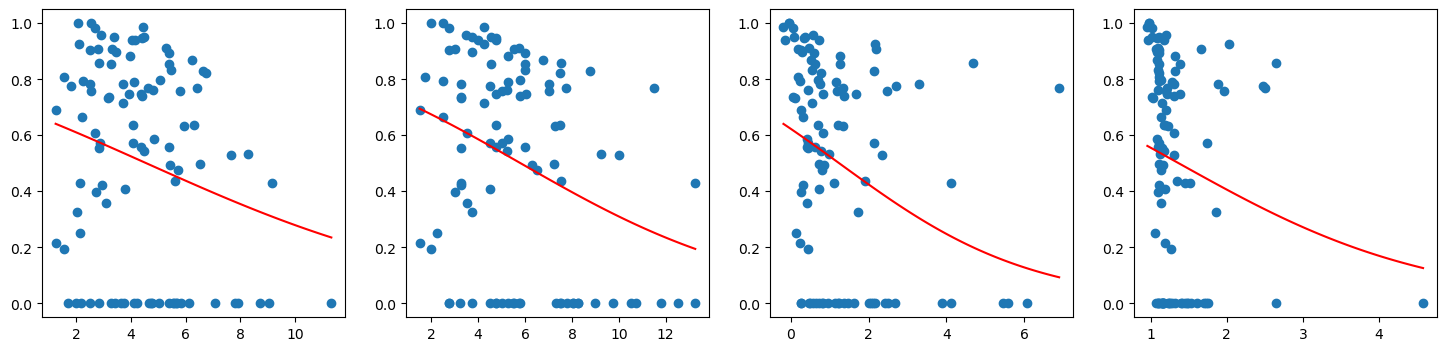

In [19]:
scatter_plot(xs, spl_summary['last'])